# 2. Python

We will be using the following PyData Tools for the Exercises:

* Pandas: <https://pandas.pydata.org/>
* NumPy: <https://numpy.org/>
* Scikit-Learn: <https://scikit-learn.org/>

This tutorial is based on:


* Wes McKinney, Python for Data Analysis, 2nd Edition, <https://github.com/wesm/pydata-book>
* <https://github.com/jonathanrocher/pandas_tutorial/blob/master/analyzing_and_manipulating_data_with_pandas_manual.pdf>




In [1]:
!git clone https://github.com/scalable-infrastructure/exercise-2026.git
%cd exercise-2026

Cloning into 'exercise-2026'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 82 (delta 35), reused 38 (delta 18), pack-reused 20 (from 3)
Receiving objects: 100% (82/82), 19.96 MiB | 23.18 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/exercise-2026


In [2]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
!pip install ".[all]"

Processing /content/exercise-2026
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.3 MB/s eta 0:00:

# 2.1 Tutorial

Follow and execute the Examples Notebooks in the Folder:

* Python and iPython Introduction
* Python Data Structures
* Pandas Tour
* NumPy Tour

# 2.2 Practical Exercise

Use the Iris dataset from the scikit-learn Dataset API to solve the following tasks:
1. How many flowers of each kind are in the dataset?
2. What is the average and standard deviation of all four attributes for all flowers and per flower group?
3. Plot the results!

In [1]:
%matplotlib inline
from sklearn import linear_model, datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
iris_df.groupby('target_name').aggregate({'target_name':'count', })

,target_name
target_name,
setosa,50
versicolor,50
virginica,50


In [5]:
print("Q2: Overall stats for ALL flowers ") # remove the non-numeric columns
print(iris_df.drop(columns=['target', 'target_name']).agg(['mean', 'std'])) # calculate mean and std for all flowers combined

Q2: Overall stats for ALL flowers 
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238


In [8]:
print("Q2: Overall stats per flower group")
print(iris_df.groupby('target_name').agg(['mean', 'std'])) # calculate mean and std per flower species

Q2: Overall stats per flower group
            sepal length (cm)           sepal width (cm)            \
                         mean       std             mean       std   
target_name                                                          
setosa                  5.006  0.352490            3.428  0.379064   
versicolor              5.936  0.516171            2.770  0.313798   
virginica               6.588  0.635880            2.974  0.322497   

            petal length (cm)           petal width (cm)           target       
                         mean       std             mean       std   mean  std  
target_name                                                                     
setosa                  1.462  0.173664            0.246  0.105386    0.0  0.0  
versicolor              4.260  0.469911            1.326  0.197753    1.0  0.0  
virginica               5.552  0.551895            2.026  0.274650    2.0  0.0  


Q3: Plot the results


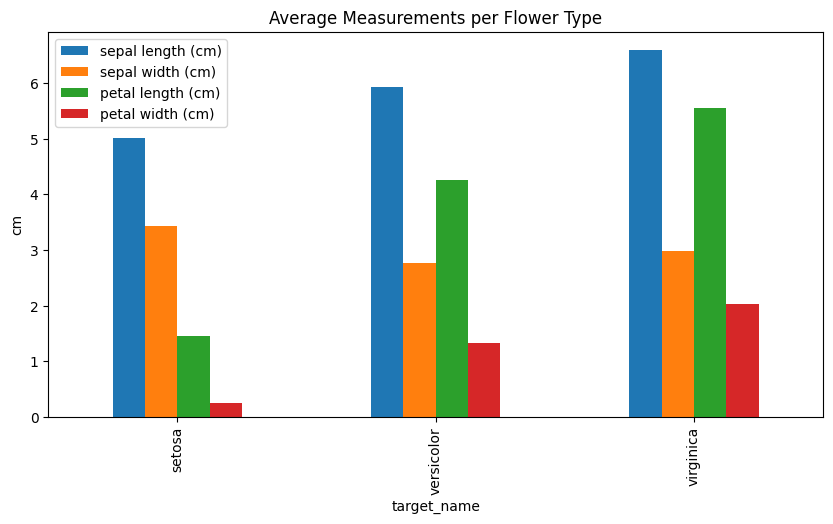

In [15]:
# Q3: Plot the results
print("Q3: Plot the results")
# Group the data by flower species
# Compute the average (mean)
iris_df.drop(columns=['target']).groupby('target_name').mean().plot(kind='bar', figsize=(10,5))
# Group the data by flower species
# Create a bar plot:
    # - one flower type
    # - each bar = one measurements
plt.title("Average Measurements per Flower Type")  # Add a title
plt.ylabel('cm')
plt.show()